# Artifacts visualization

This notebook reads experiment artifacts produced by `3_segmentation_new.ipynb` and builds comparison plots across runs plus detailed diagnostics for one selected run.

Set `ARTIFACTS_ROOT` to the folder that contains `summary.md`, `summary.jsonl`, and per-run directories. The setup cell auto-detects common locations, including `../../artifacts` from `notebooks/challenge_1/` and `artifacts` from the project root.


## Configuration

Use this cell to choose the artifacts folder and the run selection policy. `RUN_DIRS = None` means all run directories found under `ARTIFACTS_ROOT` are loaded. `SELECTED_RUN` controls which single run is used for detailed prediction diagnostics.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")

ARTIFACTS_ROOT_CANDIDATES = [
    Path("../../artifacts"),  # when kernel cwd is notebooks/challenge_1
    Path("artifacts"),       # when kernel cwd is the project root
    Path("../artifacts"),
    Path("ayana_experiments/neurosned/artifacts"),  # when kernel cwd is /home/qdata
]
ARTIFACTS_ROOT = next(
    (
        path.resolve()
        for path in ARTIFACTS_ROOT_CANDIDATES
        if (path / "summary.jsonl").exists()
        or (path / "summary.md").exists()
        or any(path.glob("*/metrics.csv"))
    ),
    Path("../../artifacts").resolve(),
)

# To force a specific folder, uncomment and edit this line:
# ARTIFACTS_ROOT = Path("/absolute/path/to/artifacts").resolve()

# None -> use every run directory discovered under ARTIFACTS_ROOT.
# Or pass run folder names / paths, for example:
# RUN_DIRS = ["SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007"]
RUN_DIRS = None

# Options: "best_holdout", "best_val", "latest", or an exact run_name / run folder name.
SELECTED_RUN = "best_holdout"

TOP_N_SUBJECTS = 20
SAVE_FIGURES = False
FIGURES_DIR = ARTIFACTS_ROOT / "visualizations"

print(f"Artifacts root: {ARTIFACTS_ROOT}")


Artifacts root: /home/qdata/ayana_experiments/neurosned/artifacts


## Helper functions

These helpers load run metadata, normalize paths, compute prediction metrics, and keep plotting behavior consistent. They avoid importing the training code or touching GPU state.


In [2]:
def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    with path.open("r") as f:
        return json.load(f)


def read_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    records = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def flatten_dict(value, prefix=""):
    out = {}
    if isinstance(value, dict):
        for key, child in value.items():
            child_prefix = f"{prefix}.{key}" if prefix else str(key)
            out.update(flatten_dict(child, child_prefix))
    else:
        out[prefix] = value
    return out


def resolve_run_dir(value, artifacts_root=ARTIFACTS_ROOT):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    path = Path(str(value))
    if path.is_absolute():
        return path

    project_root = artifacts_root.parent
    candidates = [
        (project_root / path).resolve(),
        (artifacts_root / path).resolve(),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def make_run_alias(run_name, index):
    run_name = str(run_name)
    parts = run_name.split("__")
    timestamp = parts[-1] if len(parts) > 1 else run_name[-15:]
    model = parts[0] if parts else "run"
    return f"{index + 1}. {model} {timestamp}"


def file_size_mb(path):
    path = Path(path)
    if not path.exists():
        return np.nan
    return path.stat().st_size / 1024**2


def coerce_numeric(df, columns):
    for column in columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


def load_metrics(run_dir):
    path = Path(run_dir) / "metrics.csv"
    if not path.exists():
        return pd.DataFrame()
    metrics = pd.read_csv(path)
    return coerce_numeric(metrics, metrics.columns)


def load_predictions(run_dir, filename):
    path = Path(run_dir) / filename
    if not path.exists():
        return pd.DataFrame()
    predictions = pd.read_csv(path)
    predictions = coerce_numeric(predictions, ["prediction", "target"])
    predictions = predictions.dropna(subset=["prediction", "target"])
    return predictions


def prediction_stats(predictions):
    if predictions.empty:
        return {}
    error = predictions["prediction"] - predictions["target"]
    abs_error = error.abs()
    stats = {
        "n": len(predictions),
        "rmse_sec": float(np.sqrt(np.mean(error**2))),
        "mae_sec": float(abs_error.mean()),
        "median_abs_error_sec": float(abs_error.median()),
        "bias_sec": float(error.mean()),
        "p90_abs_error_sec": float(abs_error.quantile(0.90)),
    }
    if predictions["prediction"].nunique() > 1 and predictions["target"].nunique() > 1:
        stats["corr"] = float(predictions[["prediction", "target"]].corr().iloc[0, 1])
    else:
        stats["corr"] = np.nan
    return stats


def finish_fig(fig, name=None):
    fig.tight_layout()
    if SAVE_FIGURES and name:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        path = FIGURES_DIR / f"{name}.png"
        fig.savefig(path, dpi=180, bbox_inches="tight")
        print(f"Saved: {path}")
    plt.show()


def discover_runs(artifacts_root=ARTIFACTS_ROOT, run_dirs=RUN_DIRS):
    artifacts_root = Path(artifacts_root).resolve()
    summary_records = read_jsonl(artifacts_root / "summary.jsonl")
    rows = []
    seen = set()

    for record in summary_records:
        run_dir = resolve_run_dir(record.get("run_dir"), artifacts_root)
        if run_dir is None:
            continue
        config = read_json(run_dir / "config.json")
        row = dict(record)
        row["run_dir_path"] = run_dir
        row["run_name"] = row.get("run_name") or config.get("run_name") or run_dir.name
        row["model"] = row.get("model") or config.get("model_name")
        row["created_at"] = row.get("created_at") or config.get("created_at")
        row["config"] = config
        rows.append(row)
        seen.add(run_dir.resolve())

    candidate_dirs = []
    if run_dirs is None:
        if artifacts_root.exists():
            candidate_dirs = [path for path in artifacts_root.iterdir() if path.is_dir()]
    else:
        candidate_dirs = [resolve_run_dir(value, artifacts_root) for value in run_dirs]

    for run_dir in candidate_dirs:
        if run_dir is None or not Path(run_dir).exists() or Path(run_dir).resolve() in seen:
            continue
        config = read_json(Path(run_dir) / "config.json")
        training = config.get("training_config", {})
        row = {
            "created_at": config.get("created_at"),
            "run_name": config.get("run_name") or Path(run_dir).name,
            "model": config.get("model_name"),
            "batch_size": training.get("batch_size"),
            "lr": training.get("initial_lr"),
            "sigma": training.get("sigma"),
            "temperature": training.get("temperature"),
            "lambda_time": training.get("lambda_time"),
            "lambda_ce": training.get("lambda_ce"),
            "status": "discovered",
            "run_dir": str(Path(run_dir).relative_to(artifacts_root.parent)) if artifacts_root.parent in Path(run_dir).parents else str(run_dir),
            "run_dir_path": Path(run_dir),
            "config": config,
        }
        metrics = load_metrics(run_dir)
        if not metrics.empty and "val_nrmse" in metrics.columns:
            best_idx = metrics["val_nrmse"].idxmin()
            row["best_epoch"] = int(metrics.loc[best_idx, "epoch"])
            row["best_val_nrmse"] = float(metrics.loc[best_idx, "val_nrmse"])
        rows.append(row)

    runs = pd.DataFrame(rows)
    if runs.empty:
        return runs

    numeric_columns = [
        "batch_size", "lr", "sigma", "temperature", "lambda_time", "lambda_ce",
        "best_epoch", "best_val_nrmse", "holdout_nrmse",
        "training_wall_seconds", "avg_epoch_seconds", "time_to_best_seconds", "holdout_seconds",
    ]
    runs = coerce_numeric(runs, numeric_columns)
    runs = runs.sort_values(["created_at", "run_name"], ascending=[False, True], na_position="last").reset_index(drop=True)
    runs["alias"] = [make_run_alias(name, index) for index, name in enumerate(runs["run_name"])]
    return runs


def select_run(runs, mode=SELECTED_RUN):
    if runs.empty:
        raise ValueError("No runs were discovered.")
    if mode == "best_holdout" and runs["holdout_nrmse"].notna().any():
        return runs.loc[runs["holdout_nrmse"].idxmin()]
    if mode in {"best_holdout", "best_val"} and runs["best_val_nrmse"].notna().any():
        return runs.loc[runs["best_val_nrmse"].idxmin()]
    if mode == "latest":
        return runs.iloc[0]

    exact = runs[(runs["run_name"] == mode) | (runs["run_dir_path"].map(lambda path: Path(path).name) == mode)]
    if not exact.empty:
        return exact.iloc[0]
    raise ValueError(f"Unknown SELECTED_RUN={mode!r}. Use best_holdout, best_val, latest, or an exact run name.")


## Discover available runs

This cell reads the summary file and scans all run folders. It also reports which expected artifact files exist for each run, so incomplete or interrupted runs are visible immediately.


In [3]:
runs = discover_runs()
if runs.empty:
    raise FileNotFoundError(f"No run directories found under {ARTIFACTS_ROOT}")

expected_files = [
    "config.json",
    "metrics.csv",
    "best_model.pth",
    "best_val_predictions.csv",
    "holdout_predictions.csv",
]
file_rows = []
for _, row in runs.iterrows():
    run_dir = Path(row["run_dir_path"])
    entry = {"alias": row["alias"], "run_name": row["run_name"]}
    for filename in expected_files:
        path = run_dir / filename
        entry[filename] = path.exists()
        entry[f"{filename}_mb"] = file_size_mb(path)
    file_rows.append(entry)

run_columns = [
    "alias", "created_at", "run_name", "model", "batch_size", "lr", "sigma",
    "temperature", "lambda_time", "lambda_ce", "best_epoch", "best_val_nrmse",
    "holdout_nrmse", "training_wall_seconds", "avg_epoch_seconds",
    "time_to_best_seconds", "holdout_seconds", "status", "run_dir",
]
existing_run_columns = [column for column in run_columns if column in runs.columns]

display(runs[existing_run_columns])
display(pd.DataFrame(file_rows))


,alias,created_at,run_name,model,batch_size,lr,sigma,temperature,lambda_time,lambda_ce,best_epoch,best_val_nrmse,holdout_nrmse,status,run_dir
0,1. SneddySegUNet1D 20260611_150007,2026-06-11T15:00:07Z,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007,SneddySegUNet1D,512,0.001,0.15,0.65,3.0,0,14,922.368800,934.653829,holdout_evaluated,artifacts/SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007
1,2. SneddySegUNet1D 20260611_140959,2026-06-11T14:09:59Z,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_140959,SneddySegUNet1D,512,0.001,0.15,0.65,3.0,0,16,925.247351,NaN,training_best_updated,artifacts/SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_140959


,alias,run_name,config.json,config.json_mb,metrics.csv,metrics.csv_mb,best_model.pth,best_model.pth_mb,best_val_predictions.csv,best_val_predictions.csv_mb,holdout_predictions.csv,holdout_predictions.csv_mb
0,1. SneddySegUNet1D 20260611_150007,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007,True,0.001628,True,0.021292,True,11.903143,True,0.700938,True,0.620085
1,2. SneddySegUNet1D 20260611_140959,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_140959,True,0.001628,True,0.019853,True,11.903143,True,0.700888,False,NaN


## Score overview across runs

The first comparison is intentionally simple: best validation NRMSE and holdout NRMSE per run. This is the main leaderboard view for deciding which experiment deserves deeper inspection.


,alias,run_name,best_epoch,best_val_nrmse,holdout_nrmse,status
0,1. SneddySegUNet1D 20260611_150007,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007,14,922.368800,934.653829,holdout_evaluated
1,2. SneddySegUNet1D 20260611_140959,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_140959,16,925.247351,NaN,training_best_updated


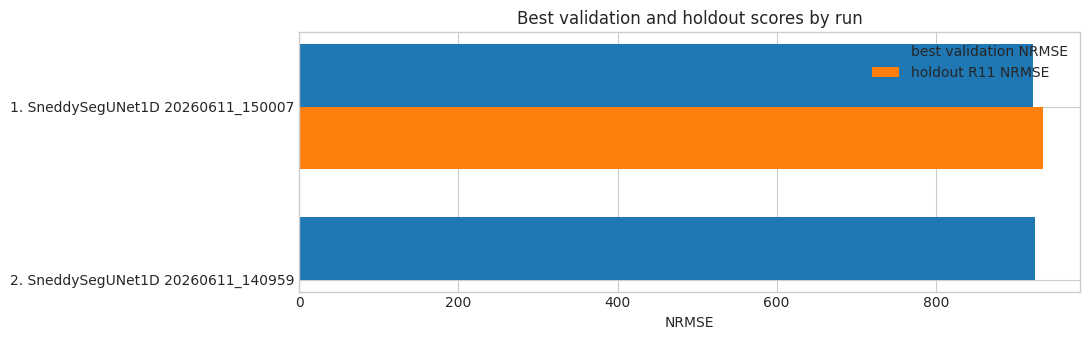

In [4]:
score_df = runs.copy()
score_df = score_df.sort_values("best_val_nrmse", na_position="last")

display(score_df[[column for column in ["alias", "run_name", "best_epoch", "best_val_nrmse", "holdout_nrmse", "status"] if column in score_df.columns]])

plot_df = score_df.set_index("alias")[[column for column in ["best_val_nrmse", "holdout_nrmse"] if column in score_df.columns]]
plot_df = plot_df.dropna(how="all")

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * len(plot_df))))
    y = np.arange(len(plot_df))
    height = 0.36
    if "best_val_nrmse" in plot_df:
        ax.barh(y - height / 2, plot_df["best_val_nrmse"], height=height, label="best validation NRMSE")
    if "holdout_nrmse" in plot_df:
        ax.barh(y + height / 2, plot_df["holdout_nrmse"], height=height, label="holdout R11 NRMSE")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df.index)
    ax.invert_yaxis()
    ax.set_xlabel("NRMSE")
    ax.set_title("Best validation and holdout scores by run")
    ax.legend()
    finish_fig(fig, "score_overview")
else:
    print("No score columns are available yet.")


## Learning curves

These plots show how validation quality evolves over epochs. `val_nrmse` is usually the most useful curve for early stopping and run comparison. Loss and learning-rate plots help diagnose unstable training or plateau restarts.


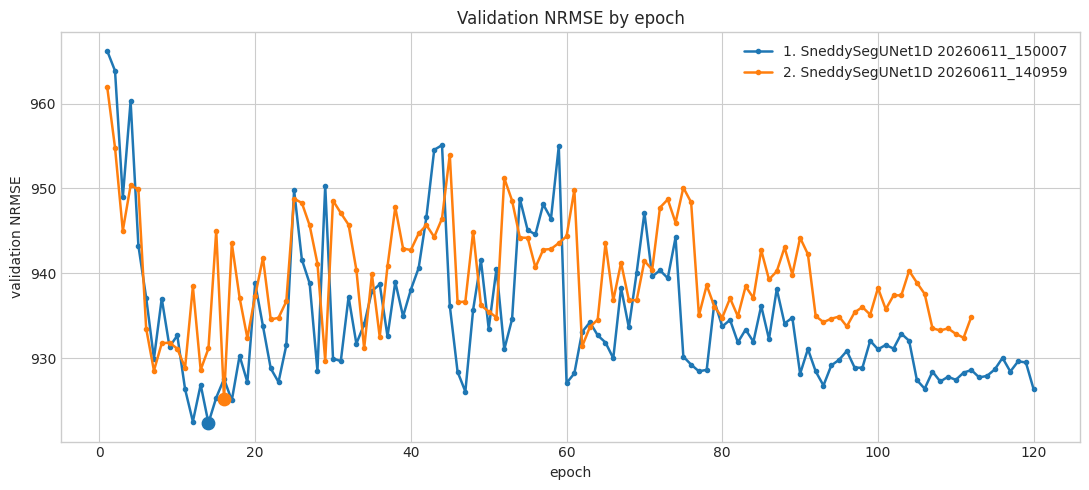

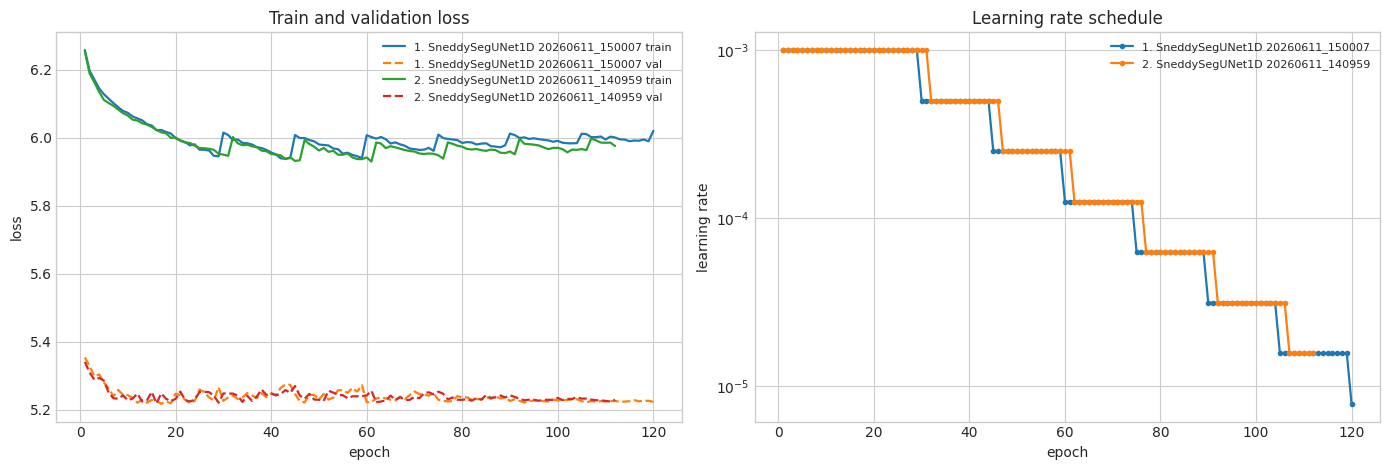

In [5]:
metrics_by_run = {}
for _, row in runs.iterrows():
    metrics = load_metrics(row["run_dir_path"])
    if not metrics.empty:
        metrics_by_run[row["alias"]] = metrics

if not metrics_by_run:
    print("No metrics.csv files found.")
else:
    if any("val_nrmse" in metrics.columns for metrics in metrics_by_run.values()):
        fig, ax = plt.subplots(figsize=(11, 5))
        for alias, metrics in metrics_by_run.items():
            if "val_nrmse" in metrics.columns:
                ax.plot(metrics["epoch"], metrics["val_nrmse"], marker="o", linewidth=1.8, markersize=3, label=alias)
                best_idx = metrics["val_nrmse"].idxmin()
                ax.scatter(metrics.loc[best_idx, "epoch"], metrics.loc[best_idx, "val_nrmse"], s=80, zorder=5)
        ax.set_xlabel("epoch")
        ax.set_ylabel("validation NRMSE")
        ax.set_title("Validation NRMSE by epoch")
        ax.legend(loc="best")
        finish_fig(fig, "learning_curve_val_nrmse")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    for alias, metrics in metrics_by_run.items():
        if "train_loss" in metrics.columns:
            axes[0].plot(metrics["epoch"], metrics["train_loss"], linewidth=1.6, label=f"{alias} train")
        if "val_loss" in metrics.columns:
            axes[0].plot(metrics["epoch"], metrics["val_loss"], linewidth=1.6, linestyle="--", label=f"{alias} val")
        if "lr" in metrics.columns:
            axes[1].plot(metrics["epoch"], metrics["lr"], marker="o", linewidth=1.6, markersize=3, label=alias)
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title("Train and validation loss")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("learning rate")
    axes[1].set_title("Learning rate schedule")
    axes[1].set_yscale("log")
    axes[0].legend(loc="best", fontsize=8)
    axes[1].legend(loc="best", fontsize=8)
    finish_fig(fig, "learning_curve_loss_lr")


## Best-epoch table

This table extracts the best validation epoch from each `metrics.csv`. It is useful when `summary.md` is stale, when a run was interrupted, or when you want to compare additional metrics at the selected epoch.


In [6]:
best_epoch_rows = []
for _, row in runs.iterrows():
    metrics = load_metrics(row["run_dir_path"])
    if metrics.empty or "val_nrmse" not in metrics.columns:
        continue
    best_idx = metrics["val_nrmse"].idxmin()
    best_row = metrics.loc[best_idx].to_dict()
    best_epoch_rows.append({
        "alias": row["alias"],
        "run_name": row["run_name"],
        "best_epoch_from_metrics": int(best_row.get("epoch")),
        "best_val_nrmse_from_metrics": best_row.get("val_nrmse"),
        "val_loss_at_best": best_row.get("val_loss"),
        "val_ce_at_best": best_row.get("val_ce"),
        "val_rmse_at_best": best_row.get("val_rmse"),
        "train_loss_at_best": best_row.get("train_loss"),
        "lr_at_best": best_row.get("lr"),
    })

best_epoch_df = pd.DataFrame(best_epoch_rows)
if best_epoch_df.empty:
    print("No best-epoch rows could be computed.")
else:
    display(best_epoch_df.sort_values("best_val_nrmse_from_metrics"))


,alias,run_name,best_epoch_from_metrics,best_val_nrmse_from_metrics,val_loss_at_best,val_ce_at_best,val_rmse_at_best,train_loss_at_best,lr_at_best
0,1. SneddySegUNet1D 20260611_150007,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007,14,922.368800,5.221042,4.850912,0.370130,6.039797,0.001
1,2. SneddySegUNet1D 20260611_140959,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_140959,16,925.247351,5.218948,4.848107,0.370841,6.022789,0.001


## Configuration comparison

This table flattens `config.json` from every run. It helps connect metrics back to model architecture and training hyperparameters without opening each run directory manually.


In [7]:
config_rows = []
for _, row in runs.iterrows():
    flat = flatten_dict(row.get("config", {}))
    flat["alias"] = row["alias"]
    flat["run_name"] = row["run_name"]
    config_rows.append(flat)

config_df = pd.DataFrame(config_rows)
preferred_columns = [
    "alias", "run_name", "model_name",
    "model_config.c0", "model_config.widen", "model_config.depth_per_stage",
    "model_config.dropout", "model_config.k",
    "training_config.batch_size", "training_config.initial_lr", "training_config.optimizer",
    "training_config.n_epochs", "training_config.early_stopping_patience",
    "training_config.sigma", "training_config.temperature",
    "training_config.lambda_time", "training_config.lambda_ce",
    "training_config.crop_proba", "training_config.cropping_offset",
    "training_config.dropout_proba", "training_config.dropout_range", "training_config.mixup_p",
    "timing.training_wall_seconds", "timing.avg_epoch_seconds",
    "timing.time_to_best_seconds", "timing.holdout_seconds",
    "data_config.split",
]
visible_columns = [column for column in preferred_columns if column in config_df.columns]
if visible_columns:
    display(config_df[visible_columns])
else:
    display(config_df)


,alias,run_name,model_name,model_config.c0,model_config.widen,model_config.depth_per_stage,model_config.dropout,model_config.k,training_config.batch_size,training_config.initial_lr,training_config.optimizer,training_config.n_epochs,training_config.early_stopping_patience,training_config.sigma,training_config.temperature,training_config.lambda_time,training_config.lambda_ce,training_config.crop_proba,training_config.cropping_offset,training_config.dropout_proba,training_config.dropout_range,training_config.mixup_p,data_config.split
0,1. SneddySegUNet1D 20260611_150007,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007,SneddySegUNet1D,96,2,5,0.2,15,512,0.001,Adam,120,15,0.15,0.65,3.0,0,0.3,0.25,0.25,0.8,0.1,"R1-R8 train, R9-R10 validation, R11 holdout"
1,2. SneddySegUNet1D 20260611_140959,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_140959,SneddySegUNet1D,96,2,5,0.2,15,512,0.001,Adam,120,15,0.15,0.65,3.0,0,0.3,0.25,0.25,0.8,0.1,"R1-R8 train, R9-R10 validation, R11 holdout"


## Select one run for detailed diagnostics

The following cells inspect validation and holdout predictions for one run. By default, the selected run is the best holdout run if holdout scores exist; otherwise it falls back to the best validation run.


In [8]:
selected_run = select_run(runs)
selected_run_dir = Path(selected_run["run_dir_path"])
print(f"Selected run: {selected_run['run_name']}")
print(f"Run directory: {selected_run_dir}")

display(selected_run[[column for column in [
    "alias", "created_at", "run_name", "model", "batch_size", "lr", "sigma", "temperature",
    "lambda_time", "lambda_ce", "best_epoch", "best_val_nrmse", "holdout_nrmse", "status"
] if column in selected_run.index]].to_frame("value"))


Selected run: SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007
Run directory: /home/qdata/ayana_experiments/neurosned/artifacts/SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007


,value
alias,1. SneddySegUNet1D 20260611_150007
created_at,2026-06-11T15:00:07Z
run_name,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007
model,SneddySegUNet1D
batch_size,512
lr,0.001
sigma,0.15
temperature,0.65
lambda_time,3.0
lambda_ce,0


## Prediction metric summary

For the selected run, this computes direct prediction-vs-target diagnostics on validation and holdout CSVs: RMSE, MAE, bias, p90 absolute error, and correlation. These are in seconds because the saved predictions and targets are in seconds.


In [9]:
prediction_files = {
    "validation": "best_val_predictions.csv",
    "holdout": "holdout_predictions.csv",
}

predictions_by_split = {}
stats_rows = []
for split, filename in prediction_files.items():
    predictions = load_predictions(selected_run_dir, filename)
    if predictions.empty:
        print(f"Missing or empty: {selected_run_dir / filename}")
        continue
    predictions_by_split[split] = predictions
    stats = prediction_stats(predictions)
    stats["split"] = split
    stats_rows.append(stats)

prediction_stats_df = pd.DataFrame(stats_rows)
if prediction_stats_df.empty:
    print("No prediction CSV files are available for the selected run.")
else:
    ordered_columns = ["split", "n", "rmse_sec", "mae_sec", "median_abs_error_sec", "p90_abs_error_sec", "bias_sec", "corr"]
    display(prediction_stats_df[[column for column in ordered_columns if column in prediction_stats_df.columns]])


,split,n,rmse_sec,mae_sec,median_abs_error_sec,p90_abs_error_sec,bias_sec,corr
0,validation,17867,0.381262,0.255786,0.167889,0.569792,-0.026861,0.392982
1,holdout,15751,0.401616,0.264212,0.167686,0.586924,0.008461,0.359753


## Prediction scatter and residual distribution

The scatter plot shows calibration against the ideal `prediction = target` diagonal. The residual histogram shows systematic bias and spread. A centered, narrow residual distribution is what we want.


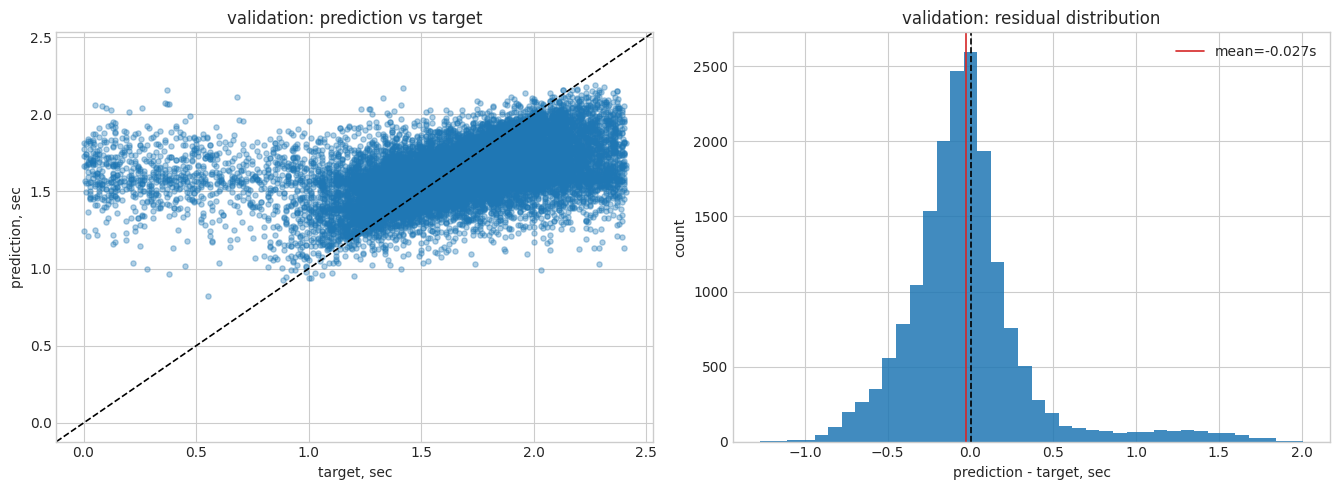

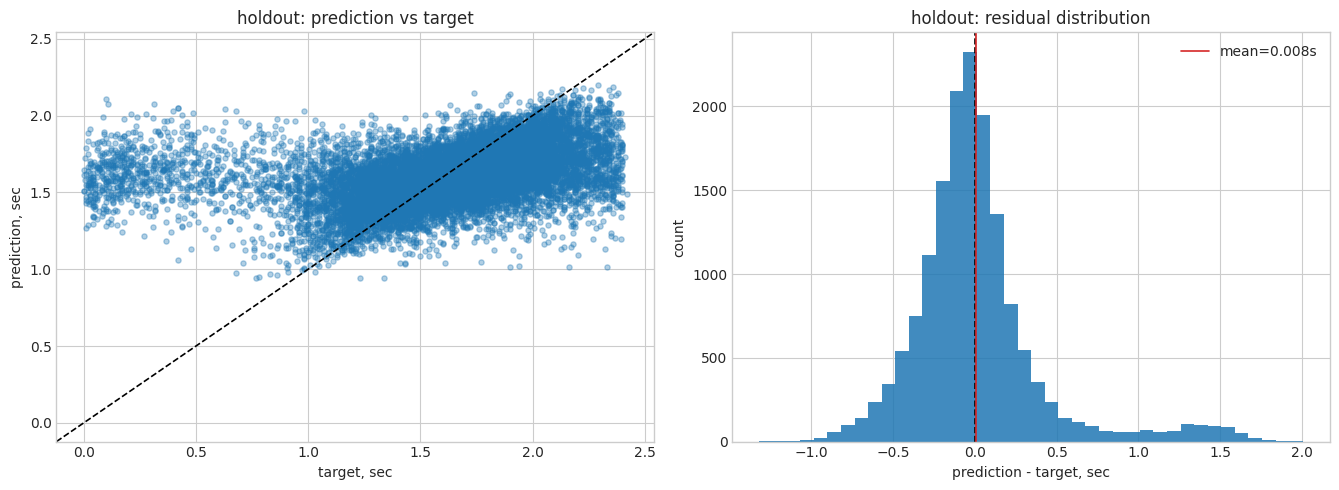

In [10]:
if not predictions_by_split:
    print("No predictions loaded.")
else:
    for split, predictions in predictions_by_split.items():
        error = predictions["prediction"] - predictions["target"]
        axis_min = min(predictions["prediction"].min(), predictions["target"].min())
        axis_max = max(predictions["prediction"].max(), predictions["target"].max())
        padding = max(0.05, 0.05 * (axis_max - axis_min))

        fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
        axes[0].scatter(predictions["target"], predictions["prediction"], s=14, alpha=0.35)
        axes[0].plot([axis_min - padding, axis_max + padding], [axis_min - padding, axis_max + padding], color="black", linewidth=1.2, linestyle="--")
        axes[0].set_xlim(axis_min - padding, axis_max + padding)
        axes[0].set_ylim(axis_min - padding, axis_max + padding)
        axes[0].set_xlabel("target, sec")
        axes[0].set_ylabel("prediction, sec")
        axes[0].set_title(f"{split}: prediction vs target")

        axes[1].hist(error, bins=40, alpha=0.85)
        axes[1].axvline(0, color="black", linewidth=1.2, linestyle="--")
        axes[1].axvline(error.mean(), color="tab:red", linewidth=1.2, label=f"mean={error.mean():.3f}s")
        axes[1].set_xlabel("prediction - target, sec")
        axes[1].set_ylabel("count")
        axes[1].set_title(f"{split}: residual distribution")
        axes[1].legend()
        finish_fig(fig, f"{selected_run['run_name']}_{split}_scatter_residuals")


## Error by target time

This plot checks whether the model is worse for early or late responses. We bin samples by target time and plot RMSE/MAE per bin, with sample counts shown in the table.


,target_bin,n,target_mean,mae_sec,rmse_sec,bias_sec
0,"(-0.00241, 0.241]",271,0.115292,1.506071,1.518380,1.506071
1,"(0.241, 0.482]",236,0.361008,1.231394,1.245896,1.231394
2,"(0.482, 0.723]",188,0.595691,0.992916,1.012398,0.992916
3,"(0.723, 0.964]",262,0.870115,0.617069,0.661966,0.617069
4,"(0.964, 1.205]",859,1.112151,0.328077,0.379749,0.324427
5,"(1.205, 1.446]",2559,1.342160,0.178034,0.221850,0.160363
6,"(1.446, 1.687]",4377,1.573158,0.098966,0.129106,0.006819
7,"(1.687, 1.928]",4795,1.801448,0.154807,0.193135,-0.133611
8,"(1.928, 2.169]",3001,2.031123,0.300179,0.345940,-0.298543
9,"(2.169, 2.41]",1319,2.270785,0.537770,0.576097,-0.537770


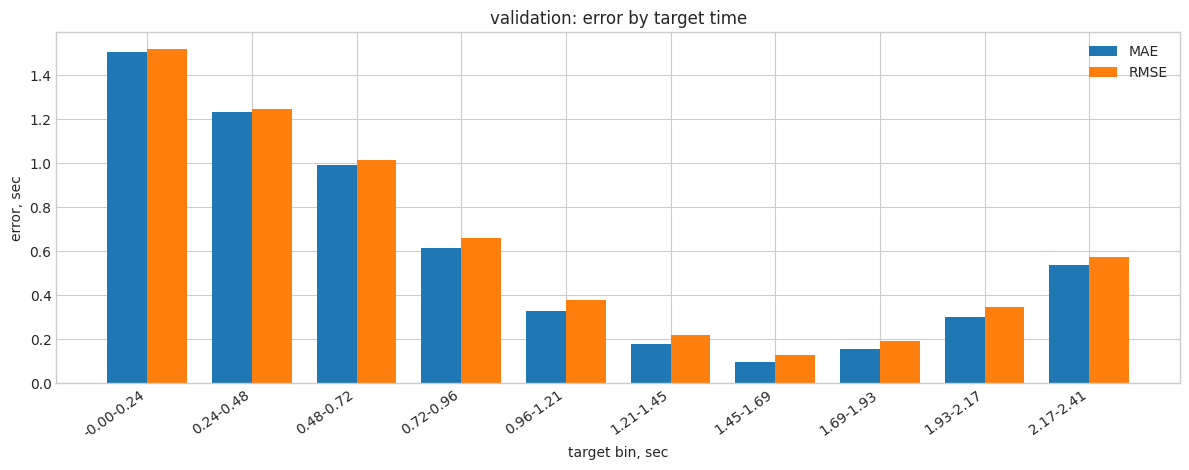

,target_bin,n,target_mean,mae_sec,rmse_sec,bias_sec
0,"(-0.00242, 0.242]",338,0.121586,1.490436,1.498036,1.490436
1,"(0.242, 0.484]",236,0.362119,1.271739,1.285622,1.271739
2,"(0.484, 0.726]",178,0.604674,0.991105,1.011977,0.991105
3,"(0.726, 0.968]",289,0.870353,0.637309,0.680232,0.637309
4,"(0.968, 1.21]",1027,1.114758,0.336494,0.389215,0.334032
5,"(1.21, 1.452]",2609,1.348724,0.168575,0.210849,0.146621
6,"(1.452, 1.694]",3993,1.580010,0.100334,0.129423,-0.006348
7,"(1.694, 1.936]",3969,1.807567,0.164465,0.203926,-0.145265
8,"(1.936, 2.178]",2233,2.037652,0.305212,0.351867,-0.303682
9,"(2.178, 2.42]",879,2.272080,0.542422,0.580300,-0.542422


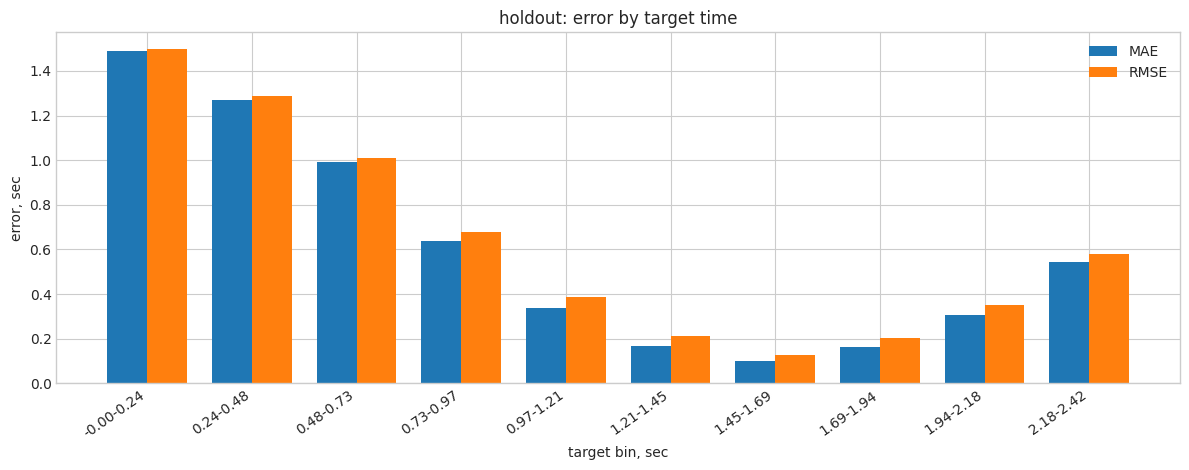

In [11]:
if not predictions_by_split:
    print("No predictions loaded.")
else:
    for split, predictions in predictions_by_split.items():
        tmp = predictions.copy()
        tmp["error"] = tmp["prediction"] - tmp["target"]
        tmp["abs_error"] = tmp["error"].abs()
        unique_targets = tmp["target"].nunique()
        n_bins = min(10, max(2, unique_targets))
        tmp["target_bin"] = pd.cut(tmp["target"], bins=n_bins, duplicates="drop")
        by_bin = tmp.groupby("target_bin", observed=True).agg(
            n=("target", "size"),
            target_mean=("target", "mean"),
            mae_sec=("abs_error", "mean"),
            rmse_sec=("error", lambda values: float(np.sqrt(np.mean(values**2)))),
            bias_sec=("error", "mean"),
        ).reset_index()
        display(by_bin)

        if not by_bin.empty:
            labels = [f"{interval.left:.2f}-{interval.right:.2f}" for interval in by_bin["target_bin"]]
            x = np.arange(len(by_bin))
            width = 0.38
            fig, ax = plt.subplots(figsize=(12, 4.8))
            ax.bar(x - width / 2, by_bin["mae_sec"], width=width, label="MAE")
            ax.bar(x + width / 2, by_bin["rmse_sec"], width=width, label="RMSE")
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=35, ha="right")
            ax.set_xlabel("target bin, sec")
            ax.set_ylabel("error, sec")
            ax.set_title(f"{split}: error by target time")
            ax.legend()
            finish_fig(fig, f"{selected_run['run_name']}_{split}_error_by_target_bin")


## Subject-level diagnostics

If the prediction CSV contains a `subject` column, this view ranks subjects by error. It helps find subjects or releases where the model behaves unusually badly and may reveal leakage, distribution shift, or noisy labels.


,subject,n,mae_sec,rmse_sec,bias_sec,target_mean,prediction_mean
214,NDARTP307VUC,66,1.172224,1.281604,1.123805,0.465212,1.589017
127,NDARJK995KMG,66,1.118057,1.188104,1.069800,0.468879,1.538679
88,NDARGC157LYY,57,0.866360,0.999587,0.737054,0.813333,1.550387
89,NDARGC407NV7,16,0.807386,0.983519,0.612557,1.026250,1.638807
276,NDARYA675XXA,7,0.886218,0.967290,0.503169,1.035429,1.538598
163,NDARNA432BV0,24,0.756831,0.940650,0.446681,1.207333,1.654014
13,NDARAV474ADJ,63,0.719136,0.916412,0.411037,1.252730,1.663767
258,NDARWP157RYM,41,0.806117,0.911714,0.676367,0.891854,1.568220
274,NDARXZ850KHQ,28,0.746434,0.895933,0.552816,1.048000,1.600816
177,NDARNT277FMR,49,0.721895,0.872740,0.544687,1.074204,1.618891


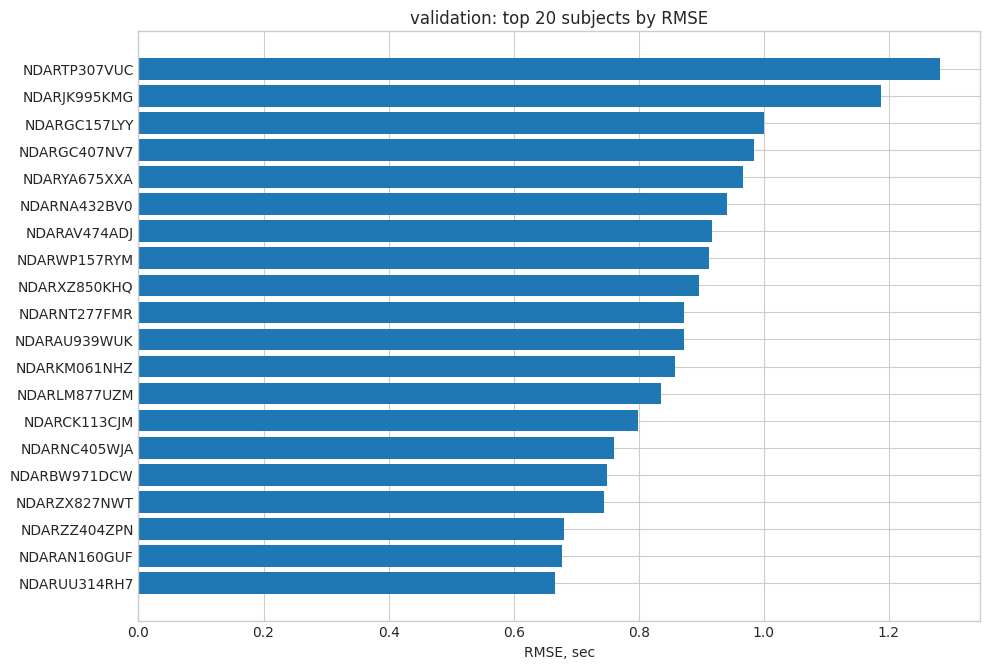

,subject,n,mae_sec,rmse_sec,bias_sec,target_mean,prediction_mean
288,NDARZA879DJG,61,1.336966,1.393826,1.307998,0.344656,1.652654
113,NDARKH524VRA,15,1.298580,1.363853,1.290424,0.413600,1.704024
31,NDARCH755TLW,69,1.293233,1.341238,1.281771,0.269159,1.550930
287,NDARZA863HD3,21,1.064864,1.160614,1.060134,0.566857,1.626991
261,NDARXC921EL3,24,0.924801,1.108059,0.883215,0.896250,1.779465
199,NDARRY803NR6,45,0.987300,1.094718,0.818012,0.824889,1.642901
42,NDARDJ872BYV,44,0.926444,1.068071,0.776270,0.836364,1.612634
231,NDARVB972ZKQ,58,0.827007,1.025355,0.785373,0.824000,1.609373
123,NDARKU213TUX,16,0.896060,1.008485,0.718860,0.870125,1.588985
148,NDARMK299CN4,67,0.779961,1.004526,0.655569,1.107284,1.762852


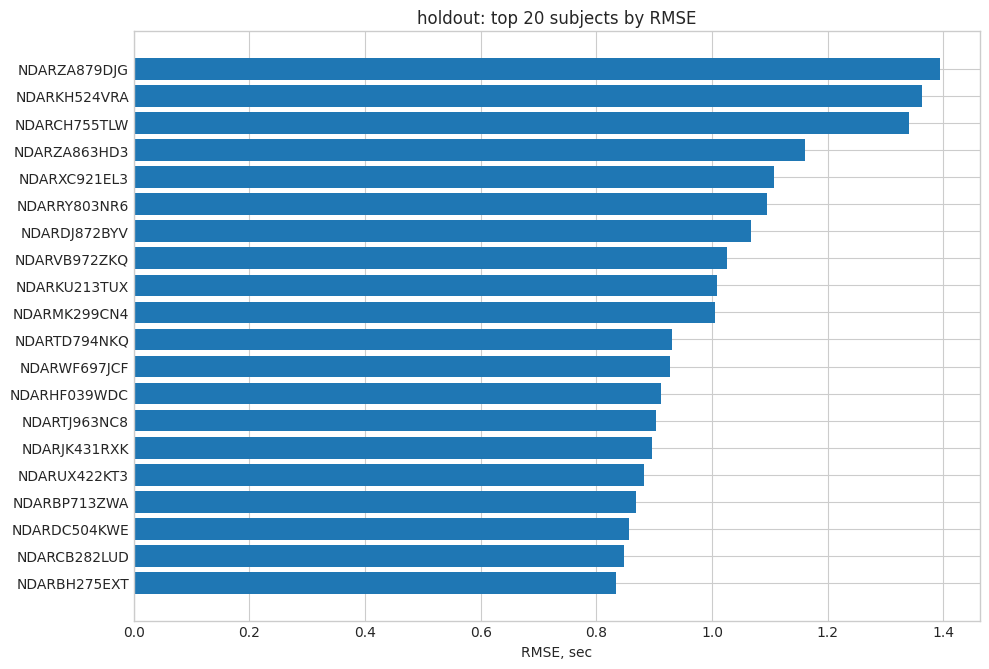

In [12]:
if not predictions_by_split:
    print("No predictions loaded.")
else:
    for split, predictions in predictions_by_split.items():
        if "subject" not in predictions.columns:
            print(f"{split}: no subject column")
            continue
        tmp = predictions.dropna(subset=["subject"]).copy()
        if tmp.empty:
            print(f"{split}: subject column is empty")
            continue
        tmp["error"] = tmp["prediction"] - tmp["target"]
        tmp["abs_error"] = tmp["error"].abs()
        by_subject = tmp.groupby("subject").agg(
            n=("target", "size"),
            mae_sec=("abs_error", "mean"),
            rmse_sec=("error", lambda values: float(np.sqrt(np.mean(values**2)))),
            bias_sec=("error", "mean"),
            target_mean=("target", "mean"),
            prediction_mean=("prediction", "mean"),
        ).reset_index()
        by_subject = by_subject.sort_values("rmse_sec", ascending=False)
        display(by_subject.head(TOP_N_SUBJECTS))

        top = by_subject.head(TOP_N_SUBJECTS).sort_values("rmse_sec")
        fig, ax = plt.subplots(figsize=(10, max(4, 0.34 * len(top))))
        ax.barh(top["subject"], top["rmse_sec"])
        ax.set_xlabel("RMSE, sec")
        ax.set_title(f"{split}: top {len(top)} subjects by RMSE")
        finish_fig(fig, f"{selected_run['run_name']}_{split}_subject_rmse")


## Multi-run prediction metrics

This final table computes the same prediction diagnostics for every run that has prediction CSVs. It complements `summary.md` because it reports MAE, bias, and correlation, not just the challenge score.


,alias,split,n,rmse_sec,mae_sec,median_abs_error_sec,p90_abs_error_sec,bias_sec,corr,run_name
1,1. SneddySegUNet1D 20260611_150007,holdout,15751,0.401616,0.264212,0.167686,0.586924,0.008461,0.359753,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007
0,1. SneddySegUNet1D 20260611_150007,validation,17867,0.381262,0.255786,0.167889,0.569792,-0.026861,0.392982,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_150007
2,2. SneddySegUNet1D 20260611_140959,validation,17867,0.382452,0.253093,0.162423,0.573526,-0.019094,0.386125,SneddySegUNet1D__c96_w2_d5__bs512__lr0p001__sig0p15__tau0p65__lt3p0_ce0__20260611_140959


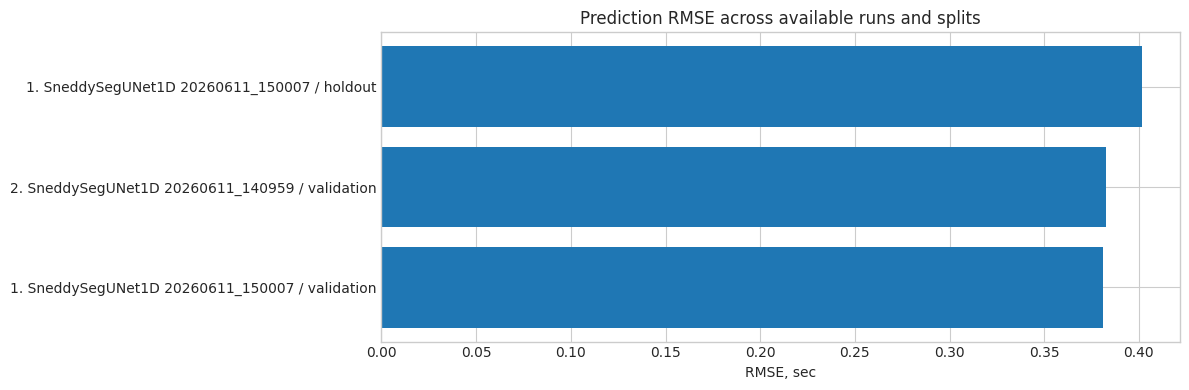

In [13]:
all_prediction_rows = []
for _, row in runs.iterrows():
    run_dir = Path(row["run_dir_path"])
    for split, filename in prediction_files.items():
        predictions = load_predictions(run_dir, filename)
        if predictions.empty:
            continue
        stats = prediction_stats(predictions)
        stats.update({
            "alias": row["alias"],
            "run_name": row["run_name"],
            "split": split,
        })
        all_prediction_rows.append(stats)

all_prediction_stats_df = pd.DataFrame(all_prediction_rows)
if all_prediction_stats_df.empty:
    print("No prediction CSV files found across runs.")
else:
    columns = ["alias", "split", "n", "rmse_sec", "mae_sec", "median_abs_error_sec", "p90_abs_error_sec", "bias_sec", "corr", "run_name"]
    display(all_prediction_stats_df[[column for column in columns if column in all_prediction_stats_df.columns]].sort_values(["split", "rmse_sec"]))

    fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(all_prediction_stats_df))))
    labels = all_prediction_stats_df["alias"] + " / " + all_prediction_stats_df["split"]
    order = np.argsort(all_prediction_stats_df["rmse_sec"].to_numpy())
    ax.barh(labels.iloc[order], all_prediction_stats_df["rmse_sec"].iloc[order])
    ax.set_xlabel("RMSE, sec")
    ax.set_title("Prediction RMSE across available runs and splits")
    finish_fig(fig, "all_runs_prediction_rmse")
